In [3]:
!python -m spacy download fr_core_news_sm 

  Using cached https://github.com/explosion/spacy-models/releases/download/fr_core_news_sm-3.8.0/fr_core_news_sm-3.8.0-py3-none-any.whl (16.3 MB)
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')


In [4]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
import spacy
import fr_core_news_sm
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("synthetic_SHS_dataset.csv") 
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    356 non-null    str  
 1   label   356 non-null    str  
dtypes: str(2)
memory usage: 153.2 KB
None
                                                text   label
0  Le cinéma français traverse une période de ren...  cinéma
1  Cannes reste le rendez-vous incontournable des...  cinéma
2  La salle obscure est bien plus qu un simple li...  cinéma
3  Le cinéma de genre connaît un engouement sans ...  cinéma
4  Les plateformes de streaming ont profondément ...  cinéma


In [6]:
categories = df.label.unique()
print(f"Nombre de categories : {len(categories)}")

Nombre de categories : 14


In [7]:
df.label.value_counts()

label
musique                42
cinéma                 39
littérature            34
patrimoine             33
danse                  29
sculpture              28
peinture               26
théâtre                25
design                 25
photographie           22
architecture           19
mode                   17
critique culturelle    10
cinéma d’animation      7
Name: count, dtype: int64

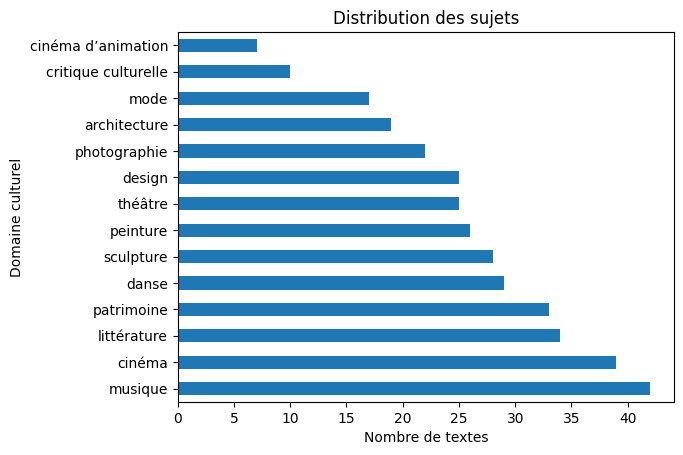

In [8]:
df.label.value_counts().plot(kind="barh")
plt.title("Distribution des sujets")
plt.xlabel("Nombre de textes")
plt.ylabel("Domaine culturel")
plt.show()

In [9]:
spacy_tokenisation_pipeline = fr_core_news_sm.load(disable=["parser", "ner"]) 

In [10]:
 # fonction pour la tokénisation qui rétourne une chaîne de caractères
def split_into_tokens(texte):
  doc = spacy_tokenisation_pipeline(texte)
  return " ".join([word.text for word in doc])

In [11]:
def split_into_tokens_no_stopwords(texte):
  doc = spacy_tokenisation_pipeline(texte)
  return " ".join([word.text for word in doc if not word.is_stop and not word.is_punct])

In [12]:
def split_into_lemmas(texte):
  doc = spacy_tokenisation_pipeline(texte)
  return " ".join([word.lemma_ for word in doc])

In [13]:
df['text_tokens'] = df.text.apply(split_into_tokens)
df['text_wosw'] = df.text.apply(split_into_tokens_no_stopwords)
df['text_lemmas'] = df.text.apply(split_into_lemmas)



In [14]:
df.head()

,text,label,text_tokens,text_wosw,text_lemmas
0,Le cinéma français traverse une période de ren...,cinéma,Le cinéma français traverse une période de ren...,cinéma français traverse période renouveau rem...,le cinéma français travers un période de renou...
1,Cannes reste le rendez-vous incontournable des...,cinéma,Cannes reste le rendez-vous incontournable des...,Cannes rendez-vous incontournable amoureux art...,Cannes reste le rendez-vous incontournable de ...
2,La salle obscure est bien plus qu un simple li...,cinéma,La salle obscure est bien plus qu un simple li...,salle obscure bien qu simple lieu divertisseme...,le salle obscur être bien plus qu un simple li...
3,Le cinéma de genre connaît un engouement sans ...,cinéma,Le cinéma de genre connaît un engouement sans ...,cinéma genre connaît engouement précédent aupr...,le cinéma de genre connaître un engouement san...
4,Les plateformes de streaming ont profondément ...,cinéma,Les plateformes de streaming ont profondément ...,plateformes streaming profondément modifié hab...,le plateforme de streaming avoir profondément ...


In [15]:
train_df, test_df = sklearn.model_selection.train_test_split(df,  train_size=0.80, test_size=0.20, random_state=42, shuffle=True, stratify=df["label"]) 

In [16]:
print(train_df.info())
print(test_df.info())

<class 'pandas.DataFrame'>
Index: 284 entries, 146 to 30
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   text         284 non-null    str  
 1   label        284 non-null    str  
 2   text_tokens  284 non-null    str  
 3   text_wosw    284 non-null    str  
 4   text_lemmas  284 non-null    str  
dtypes: str(5)
memory usage: 444.5 KB
None
<class 'pandas.DataFrame'>
Index: 72 entries, 354 to 51
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   text         72 non-null     str  
 1   label        72 non-null     str  
 2   text_tokens  72 non-null     str  
 3   text_wosw    72 non-null     str  
 4   text_lemmas  72 non-null     str  
dtypes: str(5)
memory usage: 112.6 KB
None


In [17]:
train_df.head() 

,text,label,text_tokens,text_wosw,text_lemmas
146,La sculpture africaine traditionnelle a profon...,sculpture,La sculpture africaine traditionnelle a profon...,sculpture africaine traditionnelle profondémen...,le sculpture africain traditionnel avoir profo...
300,La gastronomie française inscrite au patrimoin...,patrimoine,La gastronomie française inscrite au patrimoin...,gastronomie française inscrite patrimoine imma...,le gastronomie français inscrire au patrimoine...
40,La scène électronique berlinoise continue de f...,musique,La scène électronique berlinoise continue de f...,scène électronique berlinoise continue fascine...,le scène électronique berlinois continuer de f...
218,La breakdance a franchi un cap symbolique en i...,danse,La breakdance a franchi un cap symbolique en i...,breakdance franchi cap symbolique intégrant pr...,le breakdance avoir franchir un cap symbolique...
346,La mode durable nest plus un simple effet de t...,mode,La mode durable nest plus un simple effet de t...,mode durable nest simple tendance maisons fran...,le mode durable nest plus un simple effet de t...


In [18]:
test_df.label.value_counts()

label
musique                9
cinéma                 8
patrimoine             7
littérature            7
sculpture              6
danse                  6
design                 5
théâtre                5
peinture               5
architecture           4
photographie           4
mode                   3
critique culturelle    2
cinéma d’animation     1
Name: count, dtype: int64

In [19]:
train_df.label.value_counts()

label
musique                33
cinéma                 31
littérature            27
patrimoine             26
danse                  23
sculpture              22
peinture               21
théâtre                20
design                 20
photographie           18
architecture           15
mode                   14
critique culturelle     8
cinéma d’animation      6
Name: count, dtype: int64

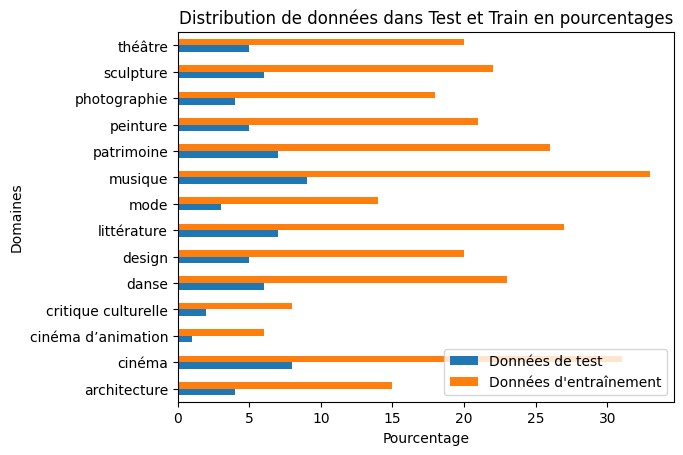

In [20]:
test_counts = test_df.label.value_counts() 
train_counts = train_df.label.value_counts()

# création d'un df
combined_counts = pd.DataFrame({
    'Données de test': test_counts,
    'Données d\'entraînement': train_counts
})

combined_counts.plot(kind="barh", stacked=False)
plt.title("Distribution de données dans Test et Train en pourcentages")
plt.xlabel("Pourcentage")
plt.ylabel("Domaines")
plt.show()

In [21]:
train_df.to_csv("data/train.csv", sep = ",", index=False) 
test_df.to_csv("data/test.csv", sep = ",", index=False)

In [22]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import string
from sklearn.compose import ColumnTransformer

# pour les modèles différents
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

# pour la validation croisée
from sklearn import metrics
from sklearn import model_selection
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# pour la visualisation
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [23]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 284 entries, 146 to 30
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   text         284 non-null    str  
 1   label        284 non-null    str  
 2   text_tokens  284 non-null    str  
 3   text_wosw    284 non-null    str  
 4   text_lemmas  284 non-null    str  
dtypes: str(5)
memory usage: 444.5 KB


In [24]:
train_df['label'] = train_df['label'].astype('category')
for col in train_df.columns:
    if col != 'label':
        train_df[col] = train_df[col].astype('object')
        

In [25]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 284 entries, 146 to 30
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   text         284 non-null    object  
 1   label        284 non-null    category
 2   text_tokens  284 non-null    object  
 3   text_wosw    284 non-null    object  
 4   text_lemmas  284 non-null    object  
dtypes: category(1), object(4)
memory usage: 11.6+ KB


First variant: with spacy-tokenised words

In [26]:
X_train = train_df[['text_tokens']]
y_train = train_df.label




In [27]:
 # fonction de tokénisation
def split_text(text) :
  # Les textes ayant déjà été pré-tokénisés, on découpe au niveau des espaces
  return text.split(' ')

In [28]:
text_vectorizer = TfidfVectorizer(tokenizer=split_text,
                                  #la proportion minimale des documents dans lesquels un token doit se trouver, soit 1%
                                  min_df=0.01)

In [29]:
column_trans = ColumnTransformer([(
         'description_tfidf', text_vectorizer, 'text_tokens')],
     # Autres colonnes ignorées
     remainder='drop')

In [30]:
models = [
    # baseline : tous les cas sont classés dans la classe la plus représentée
    ('Baseline', DummyClassifier(strategy='most_frequent')),
    ('Multinomial NB', MultinomialNB()),
    ('CART', DecisionTreeClassifier()),
    ('LR', LogisticRegression()),
    ('KNN', KNeighborsClassifier()),
    ('Random forest', RandomForestClassifier()),
    ('LinearSVC', LinearSVC()),
]

# Évaluation des résultats les uns après les autres
scores =[]
names = []
scoring = 'macro F1'

# Validation croisée à 5 plis avec StratifiedKFold
# StratifiedKFold et pas KFold, car les classes ne sont pas équilibrées

kfold = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state = 12)

for name,  model in models:
  names.append(name)
  model_pipeline = make_pipeline(column_trans, model)
  y_pred = model_selection.cross_val_predict(model_pipeline, X_train, y_train, cv=kfold)
  print(name)
  print(classification_report(y_train, y_pred))
  f1 = metrics.f1_score(y_train, y_pred, average = "macro")
  scores.append(f1)


c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_patt

Baseline
                     precision    recall  f1-score   support

       architecture       0.00      0.00      0.00        15
             cinéma       0.00      0.00      0.00        31
 cinéma d’animation       0.00      0.00      0.00         6
critique culturelle       0.00      0.00      0.00         8
              danse       0.00      0.00      0.00        23
             design       0.00      0.00      0.00        20
        littérature       0.00      0.00      0.00        27
               mode       0.00      0.00      0.00        14
            musique       0.12      1.00      0.21        33
         patrimoine       0.00      0.00      0.00        26
           peinture       0.00      0.00      0.00        21
       photographie       0.00      0.00      0.00        18
          sculpture       0.00      0.00      0.00        22
            théâtre       0.00      0.00      0.00        20

           accuracy                           0.12       284
          mac

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\an

CART
                     precision    recall  f1-score   support

       architecture       0.25      0.20      0.22        15
             cinéma       0.73      0.61      0.67        31
 cinéma d’animation       0.50      0.33      0.40         6
critique culturelle       0.00      0.00      0.00         8
              danse       0.70      0.70      0.70        23
             design       0.95      0.95      0.95        20
        littérature       0.58      0.67      0.62        27
               mode       0.54      0.50      0.52        14
            musique       0.75      0.73      0.74        33
         patrimoine       0.67      0.85      0.75        26
           peinture       0.40      0.48      0.43        21
       photographie       0.60      0.67      0.63        18
          sculpture       0.83      0.68      0.75        22
            théâtre       0.67      0.80      0.73        20

           accuracy                           0.64       284
          macro a

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is 

LR
                     precision    recall  f1-score   support

       architecture       1.00      0.07      0.12        15
             cinéma       0.49      0.87      0.63        31
 cinéma d’animation       0.00      0.00      0.00         6
critique culturelle       0.00      0.00      0.00         8
              danse       0.82      0.61      0.70        23
             design       0.94      0.80      0.86        20
        littérature       0.77      0.85      0.81        27
               mode       0.00      0.00      0.00        14
            musique       0.38      0.94      0.54        33
         patrimoine       0.67      0.85      0.75        26
           peinture       0.77      0.48      0.59        21
       photographie       0.90      0.50      0.64        18
          sculpture       0.82      0.64      0.72        22
            théâtre       1.00      0.45      0.62        20

           accuracy                           0.62       284
          macro avg

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_patt

Random forest
                     precision    recall  f1-score   support

       architecture       0.55      0.40      0.46        15
             cinéma       0.71      0.77      0.74        31
 cinéma d’animation       1.00      0.17      0.29         6
critique culturelle       0.00      0.00      0.00         8
              danse       0.86      0.78      0.82        23
             design       0.90      0.95      0.93        20
        littérature       0.75      0.89      0.81        27
               mode       0.70      0.50      0.58        14
            musique       0.80      0.85      0.82        33
         patrimoine       0.70      0.81      0.75        26
           peinture       0.68      0.62      0.65        21
       photographie       0.75      0.83      0.79        18
          sculpture       0.81      0.95      0.88        22
            théâtre       0.79      0.95      0.86        20

           accuracy                           0.76       284
        

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

Second variant: without stop words

In [31]:
X_train = train_df[['text_wosw']]
y_train = train_df.label

In [32]:
column_trans = ColumnTransformer([(
         'text_wosw_tfidf', text_vectorizer, 'text_wosw')],
     remainder='drop')

In [33]:
scores_wosw =[]
names = []
scoring = 'macro F1'

kfold = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state = 12)

for name,  model in models:
  names.append(name)
  model_pipeline = make_pipeline(column_trans, model)
  y_pred = model_selection.cross_val_predict(model_pipeline, X_train, y_train, cv=kfold)
  print(name)
  print(classification_report(y_train, y_pred))
  f1 = metrics.f1_score(y_train, y_pred, average = "macro")
  scores_wosw.append(f1)

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_patt

Baseline
                     precision    recall  f1-score   support

       architecture       0.00      0.00      0.00        15
             cinéma       0.00      0.00      0.00        31
 cinéma d’animation       0.00      0.00      0.00         6
critique culturelle       0.00      0.00      0.00         8
              danse       0.00      0.00      0.00        23
             design       0.00      0.00      0.00        20
        littérature       0.00      0.00      0.00        27
               mode       0.00      0.00      0.00        14
            musique       0.12      1.00      0.21        33
         patrimoine       0.00      0.00      0.00        26
           peinture       0.00      0.00      0.00        21
       photographie       0.00      0.00      0.00        18
          sculpture       0.00      0.00      0.00        22
            théâtre       0.00      0.00      0.00        20

           accuracy                           0.12       284
          mac

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction

CART
                     precision    recall  f1-score   support

       architecture       0.29      0.47      0.36        15
             cinéma       0.84      0.68      0.75        31
 cinéma d’animation       0.50      0.33      0.40         6
critique culturelle       0.25      0.12      0.17         8
              danse       0.54      0.57      0.55        23
             design       1.00      0.95      0.97        20
        littérature       0.81      0.63      0.71        27
               mode       0.56      0.71      0.62        14
            musique       0.84      0.82      0.83        33
         patrimoine       0.76      0.73      0.75        26
           peinture       0.48      0.67      0.56        21
       photographie       0.68      0.72      0.70        18
          sculpture       0.95      0.82      0.88        22
            théâtre       0.90      0.95      0.93        20

           accuracy                           0.70       284
          macro a

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_patt

...

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_patt

KNN
                     precision    recall  f1-score   support

       architecture       0.29      0.27      0.28        15
             cinéma       0.61      0.74      0.67        31
 cinéma d’animation       0.50      0.50      0.50         6
critique culturelle       0.71      0.62      0.67         8
              danse       0.65      0.74      0.69        23
             design       0.81      0.85      0.83        20
        littérature       0.79      0.85      0.82        27
               mode       0.60      0.43      0.50        14
            musique       0.72      0.79      0.75        33
         patrimoine       0.68      0.65      0.67        26
           peinture       0.61      0.52      0.56        21
       photographie       0.79      0.61      0.69        18
          sculpture       0.71      0.55      0.62        22
            théâtre       0.74      0.85      0.79        20

           accuracy                           0.68       284
          macro av

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Random forest
                     precision    recall  f1-score   support

       architecture       0.38      0.40      0.39        15
             cinéma       0.79      0.84      0.81        31
 cinéma d’animation       0.00      0.00      0.00         6
critique culturelle       1.00      0.12      0.22         8
              danse       0.74      0.87      0.80        23
             design       0.95      1.00      0.98        20
        littérature       0.79      0.96      0.87        27
               mode       0.69      0.64      0.67        14
            musique       0.88      0.85      0.86        33
         patrimoine       0.81      0.85      0.83        26
           peinture       0.83      0.71      0.77        21
       photographie       0.78      0.78      0.78        18
          sculpture       0.74      0.77      0.76        22
            théâtre       0.86      0.95      0.90        20

           accuracy                           0.79       284
        

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

Third variant: with lemmatised words

In [34]:
X_train = train_df[['text_lemmas']]
y_train = train_df.label

In [35]:
column_trans = ColumnTransformer([(
         'text_lemmas_tfidf', text_vectorizer, 'text_lemmas')],
     remainder='drop')

In [39]:
scores_lem =[]
names = []
scoring = 'macro F1'

kfold = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state = 12)

for name,  model in models:
  names.append(name)
  model_pipeline = make_pipeline(column_trans, model)
  y_pred = model_selection.cross_val_predict(model_pipeline, X_train, y_train, cv=kfold)
  print(name)
  print(classification_report(y_train, y_pred))
  f1 = metrics.f1_score(y_train, y_pred, average = "macro")
  scores_lem.append(f1)

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_patt

Baseline
                     precision    recall  f1-score   support

       architecture       0.00      0.00      0.00        15
             cinéma       0.00      0.00      0.00        31
 cinéma d’animation       0.00      0.00      0.00         6
critique culturelle       0.00      0.00      0.00         8
              danse       0.00      0.00      0.00        23
             design       0.00      0.00      0.00        20
        littérature       0.00      0.00      0.00        27
               mode       0.00      0.00      0.00        14
            musique       0.12      1.00      0.21        33
         patrimoine       0.00      0.00      0.00        26
           peinture       0.00      0.00      0.00        21
       photographie       0.00      0.00      0.00        18
          sculpture       0.00      0.00      0.00        22
            théâtre       0.00      0.00      0.00        20

           accuracy                           0.12       284
          mac

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_patt

CART
                     precision    recall  f1-score   support

       architecture       0.23      0.20      0.21        15
             cinéma       0.80      0.65      0.71        31
 cinéma d’animation       0.60      0.50      0.55         6
critique culturelle       0.00      0.00      0.00         8
              danse       0.50      0.65      0.57        23
             design       1.00      0.95      0.97        20
        littérature       0.71      0.81      0.76        27
               mode       0.50      0.43      0.46        14
            musique       0.81      0.76      0.78        33
         patrimoine       0.65      0.77      0.70        26
           peinture       0.31      0.38      0.34        21
       photographie       0.81      0.72      0.76        18
          sculpture       0.90      0.82      0.86        22
            théâtre       0.78      0.70      0.74        20

           accuracy                           0.65       284
          macro a

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is 

...

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


KNN
                     precision    recall  f1-score   support

       architecture       0.75      0.40      0.52        15
             cinéma       0.63      0.77      0.70        31
 cinéma d’animation       0.60      0.50      0.55         6
critique culturelle       0.57      0.50      0.53         8
              danse       0.51      0.83      0.63        23
             design       0.75      0.75      0.75        20
        littérature       0.75      0.67      0.71        27
               mode       0.60      0.21      0.32        14
            musique       0.69      0.76      0.72        33
         patrimoine       0.70      0.73      0.72        26
           peinture       0.67      0.67      0.67        21
       photographie       0.87      0.72      0.79        18
          sculpture       0.76      0.73      0.74        22
            théâtre       0.80      0.80      0.80        20

           accuracy                           0.69       284
          macro av

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Random forest
                     precision    recall  f1-score   support

       architecture       0.46      0.40      0.43        15
             cinéma       0.68      0.87      0.76        31
 cinéma d’animation       0.00      0.00      0.00         6
critique culturelle       0.00      0.00      0.00         8
              danse       0.69      0.78      0.73        23
             design       1.00      1.00      1.00        20
        littérature       0.84      0.96      0.90        27
               mode       0.78      0.50      0.61        14
            musique       0.83      0.88      0.85        33
         patrimoine       0.68      0.88      0.77        26
           peinture       0.94      0.76      0.84        21
       photographie       0.81      0.94      0.87        18
          sculpture       0.90      0.82      0.86        22
            théâtre       0.94      0.85      0.89        20

           accuracy                           0.79       284
        

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

In [41]:
results_df = pd.DataFrame(
    {
        "model_names" : names,
        "no_preprocessing_scores" : scores,
        "wosw_scores" : scores_wosw,
        "scores_lem" : scores_lem

    }
)

results_df

,model_names,no_preprocessing_scores,wosw_scores,scores_lem
0,Baseline,0.014872,0.014872,0.014872
1,Multinomial NB,0.303843,0.496712,0.312509
2,CART,0.578686,0.655712,0.601193
3,LR,0.498530,0.539320,0.498386
4,KNN,0.642611,0.645125,0.652967
5,Random forest,0.669947,0.687844,0.679605
6,LinearSVC,0.751551,0.743919,0.746529


In [42]:
X_train = train_df['text_tokens']
y_train = train_df.label
X_test = test_df['text_tokens']
y_test = test_df.label

column_trans = ColumnTransformer([(
         'description_tfidf', text_vectorizer, 'text_tokens')],
     remainder='drop')

classifier_pipeline = make_pipeline(
    text_vectorizer,
    LinearSVC()
)

classifier_pipeline.fit(X_train, y_train)

y_pred = classifier_pipeline.predict(X_test)
print("Classification report:\n{}".format(classification_report(y_test, y_pred)))

# sauvegarder le score f1 et calculer l'exactitude
accuracy = accuracy_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred, average = "macro")
print(f"Exactitude : {accuracy}")

c:\Users\antoi\Documents\projects\project1\venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Classification report:
                     precision    recall  f1-score   support

       architecture       1.00      0.50      0.67         4
             cinéma       0.89      1.00      0.94         8
 cinéma d’animation       1.00      1.00      1.00         1
critique culturelle       1.00      0.50      0.67         2
              danse       0.67      0.67      0.67         6
             design       1.00      1.00      1.00         5
        littérature       0.88      1.00      0.93         7
               mode       1.00      1.00      1.00         3
            musique       0.67      0.67      0.67         9
         patrimoine       0.88      1.00      0.93         7
           peinture       1.00      0.60      0.75         5
       photographie       0.60      0.75      0.67         4
          sculpture       0.86      1.00      0.92         6
            théâtre       1.00      1.00      1.00         5

           accuracy                           0.85        72

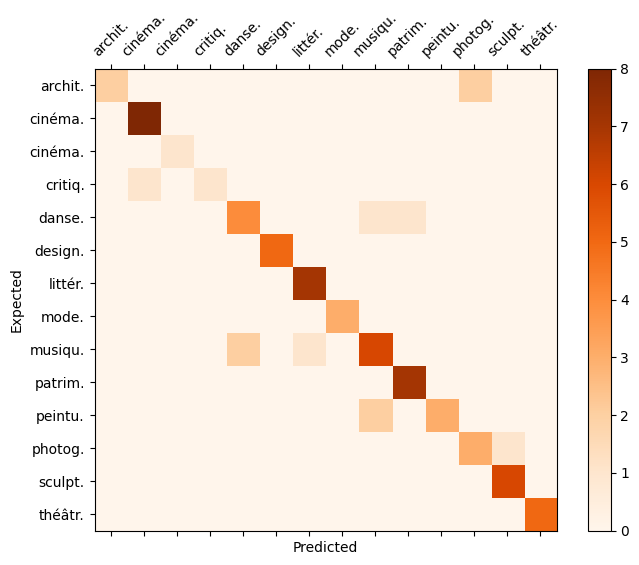

In [43]:
labels = np.unique(y_test)
cm =  confusion_matrix(y_test, y_pred, labels=labels)
confusion_df = pd.DataFrame(cm, index=labels, columns=labels)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
cax = ax.matshow(cm, interpolation='nearest', cmap=plt.cm.Oranges)
fig.colorbar(cax)
tick_marks = np.arange(len(labels))
labels_for_fig = [l[0:6]+'.' for l in labels]
plt.xticks(tick_marks, labels_for_fig, rotation=45)
plt.yticks(tick_marks, labels_for_fig)
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.show()